In [2]:
import pandas as pd
import numpy as np
import joblib
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import json
import hashlib
from datetime import datetime
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, RocCurveDisplay, ConfusionMatrixDisplay, accuracy_score
from xgboost import XGBClassifier

In [3]:
DATASET_PATH = 'FINAL_ai_human_music_detector_dataset.csv'
RANDOM_STATE = 42
TEST_SIZE = 0.15
VAL_SIZE_FROM_TEMP = 0.176  # approximately 15% of the full dataset after the test split

df = pd.read_csv(DATASET_PATH)

feature_cols = [c for c in df.columns if c not in ['label', 'filename']]
X = df[feature_cols].values
y = df['label'].values
filenames = df['filename'].values

# 70 / 15 / 15 split.
# Test is reserved for the final evaluation only; model selection uses validation metrics.
X_temp, X_test, y_temp, y_test, filenames_temp, filenames_test = train_test_split(
    X, y, filenames, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
X_train, X_val, y_train, y_val, filenames_train, filenames_val = train_test_split(
    X_temp, y_temp, filenames_temp, test_size=VAL_SIZE_FROM_TEMP,
    random_state=RANDOM_STATE, stratify=y_temp
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print(f'Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')
print(f'Features: {len(feature_cols)}')
print('Selection split: validation')
print('Final evaluation split: test')


Train: 308 | Val: 66 | Test: 66
Features: 104
Selection split: validation
Final evaluation split: test


In [4]:
lr  = LogisticRegression(max_iter=1000, random_state=42)

xgb = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, eval_metric='logloss', random_state=42)

rf  = RandomForestClassifier(n_estimators=200, random_state=42)

gb  = GradientBoostingClassifier(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42)

svm = SVC(probability=True, kernel='rbf', random_state=42)

knn = KNeighborsClassifier(n_neighbors=5)

for name, m in [('LR', lr), ('XGB', xgb), ('RF', rf),
                ('GB', gb), ('SVM', svm), ('KNN', knn)]:
    m.fit(X_train_s, y_train)
    print(f'{name} trained')

print('\nAll base models trained.')

LR trained
XGB trained
RF trained
GB trained
SVM trained
KNN trained

All base models trained.


In [5]:
def make_lr(): 
    return LogisticRegression(max_iter=1000, random_state=42)
    
def make_xgb(): 
    return XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, 
                         eval_metric='logloss', random_state=42)
    
def make_rf():
    return RandomForestClassifier(n_estimators=200, random_state=42)
    
def make_gb():  
    return GradientBoostingClassifier(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42)
    
def make_svm(): 
    return SVC(probability=True, kernel='rbf', random_state=42)

# Voting Ensembles 
vote_lr_gb = VotingClassifier(
    estimators=[('lr', make_lr()), ('gb', make_gb())], voting='soft')

vote_xgb_rf = VotingClassifier(
    estimators=[('xgb', make_xgb()), ('rf', make_rf())], voting='soft')

vote_all5 = VotingClassifier(
    estimators=[('lr', make_lr()), ('xgb', make_xgb()), ('rf', make_rf()),
                ('gb', make_gb()), ('svm', make_svm())], voting='soft')

vote_lr_xgb_rf_gb = VotingClassifier(
    estimators=[('lr', make_lr()), ('xgb', make_xgb()),
                ('rf', make_rf()),  ('gb', make_gb())], voting='soft')

vote_lr_xgb_gb = VotingClassifier(
    estimators=[('lr', make_lr()), ('xgb', make_xgb()), ('gb', make_gb())], voting='soft')

vote_xgb_gb_svm = VotingClassifier(
    estimators=[('xgb', make_xgb()), ('gb', make_gb()), ('svm', make_svm())], voting='soft')

# Stacking ensembles 
stack_xgb_rf_lr = StackingClassifier(
    estimators=[('xgb', make_xgb()), ('rf', make_rf())],
    final_estimator=make_lr(), cv=5)

stack_lr_xgb_gb_lr = StackingClassifier(
    estimators=[('lr', make_lr()), ('xgb', make_xgb()), ('gb', make_gb())],
    final_estimator=make_lr(), cv=5)

ensemble_models = {
    'Vote: LR+GB':            vote_lr_gb,
    'Vote: XGB+RF':           vote_xgb_rf,
    'Vote: ALL 5':            vote_all5,
    'Vote: LR+XGB+RF+GB':     vote_lr_xgb_rf_gb,
    'Vote: LR+XGB+GB':        vote_lr_xgb_gb,
    'Vote: XGB+GB+SVM':       vote_xgb_gb_svm,
    'Stack: LR+XGB+GB -> LR':  stack_lr_xgb_gb_lr,
    'Stack: XGB+RF -> LR':     stack_xgb_rf_lr   
}

for name, m in ensemble_models.items():
    m.fit(X_train_s, y_train)
    print(f'{name} trained')

Vote: LR+GB trained
Vote: XGB+RF trained
Vote: ALL 5 trained
Vote: LR+XGB+RF+GB trained
Vote: LR+XGB+GB trained
Vote: XGB+GB+SVM trained
Stack: LR+XGB+GB -> LR trained
Stack: XGB+RF -> LR trained


## 4. Validation Leaderboard - All Models


In [6]:
all_models = {
    'Vote: LR+GB':            vote_lr_gb,
    'Vote: XGB+RF':           vote_xgb_rf,
    'Vote: ALL 5':            vote_all5,
    'Vote: LR+XGB+RF+GB':     vote_lr_xgb_rf_gb,
    'Vote: LR+XGB+GB':        vote_lr_xgb_gb,
    'Vote: XGB+GB+SVM':       vote_xgb_gb_svm,
    'Stack: LR+XGB+GB -> LR': stack_lr_xgb_gb_lr,
    'Stack: XGB+RF -> LR':    stack_xgb_rf_lr,
    'XGBoost':                xgb,
    'Logistic Regression':    lr,
    'Random Forest':          rf,
    'Gradient Boosting':      gb,
    'SVM':                    svm,
    'KNN':                    knn,
}

rows = []
results_store = {}

for name, m in all_models.items():
    pred  = m.predict(X_val_s)
    proba = m.predict_proba(X_val_s)[:, 1]
    acc   = accuracy_score(y_val, pred)
    auc   = roc_auc_score(y_val, proba)
    rep   = classification_report(y_val, pred, target_names=['Human', 'AI'], output_dict=True, zero_division=0)
    cm    = confusion_matrix(y_val, pred)
    tn, fp, fn, tp = cm.ravel()
    prec  = rep['AI']['precision']
    rec   = rep['AI']['recall']
    f1    = rep['AI']['f1-score']
    rows.append({'Model': name, 'Acc': acc, 'AUC': auc,
                 'Prec(AI)': prec, 'Rec(AI)': rec, 'F1(AI)': f1, 'FP': fp, 'FN': fn})
    results_store[name] = {'model': m, 'pred': pred, 'proba': proba,
                            'acc': acc, 'auc': auc, 'f1': f1, 'cm': cm, 'split': 'validation'}

leaderboard_df = pd.DataFrame(rows).sort_values(
    ['F1(AI)', 'AUC', 'Acc'], ascending=False
).reset_index(drop=True)
leaderboard_df.insert(0, 'Rank', np.arange(1, len(leaderboard_df) + 1))

print('VALIDATION LEADERBOARD - model selection uses validation only')
print('-' * 95)
print(f"{'Rank':<5} {'Model':<28} {'Acc':>6} {'AUC':>7} {'Prec(AI)':>9} {'Rec(AI)':>8} {'F1(AI)':>7} {'FP':>4} {'FN':>4}")
print('-' * 95)
for _, row in leaderboard_df.iterrows():
    print(f"{int(row['Rank']):<5} {row['Model']:<28} {row['Acc']*100:>5.1f}% {row['AUC']:>7.4f} "
          f"{row['Prec(AI)']:>9.3f} {row['Rec(AI)']:>8.3f} {row['F1(AI)']:>7.3f} {int(row['FP']):>4} {int(row['FN']):>4}")


VALIDATION LEADERBOARD - model selection uses validation only
-----------------------------------------------------------------------------------------------
Rank  Model                           Acc     AUC  Prec(AI)  Rec(AI)  F1(AI)   FP   FN
-----------------------------------------------------------------------------------------------
1     Vote: LR+XGB+GB               93.9%  0.9908     0.892    1.000   0.943    4    0
2     Vote: LR+XGB+RF+GB            90.9%  0.9881     0.865    0.970   0.914    5    1
3     Vote: ALL 5                   90.9%  0.9816     0.865    0.970   0.914    5    1
4     Stack: XGB+RF -> LR           90.9%  0.9761     0.886    0.939   0.912    4    2
5     Vote: XGB+RF                  90.9%  0.9752     0.886    0.939   0.912    4    2
6     Stack: LR+XGB+GB -> LR        89.4%  0.9890     0.842    0.970   0.901    6    1
7     Vote: LR+GB                   89.4%  0.9881     0.842    0.970   0.901    6    1
8     Random Forest                 89.4%  0.9656 

## Confusion Matrices : All Models

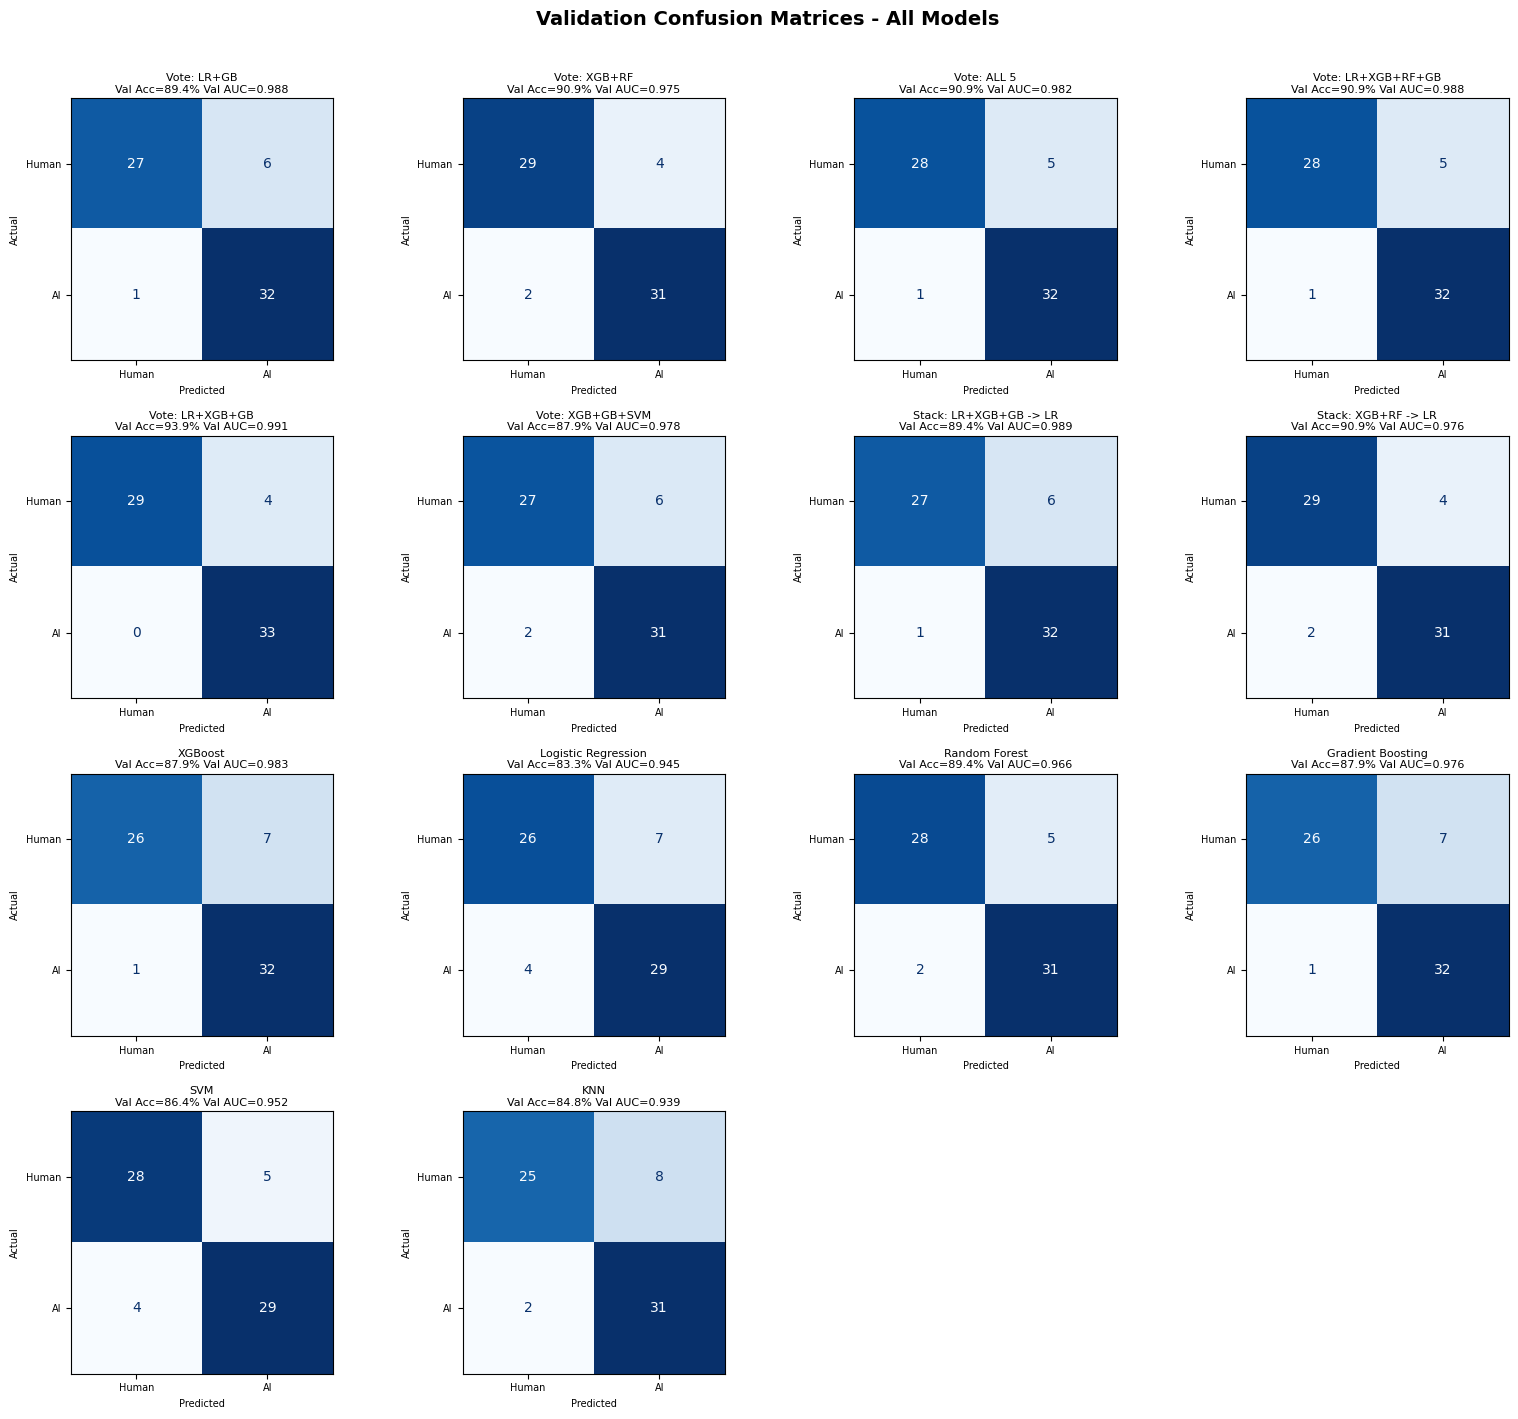

Saved: confusion_matrices_all.png


In [7]:
n_models = len(all_models)
ncols = 4
nrows = int(np.ceil(n_models / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3.5))
axes = axes.flatten()

for idx, (name, res) in enumerate(results_store.items()):
    disp = ConfusionMatrixDisplay(confusion_matrix=res['cm'], display_labels=['Human', 'AI'])
    disp.plot(ax=axes[idx], colorbar=False, cmap='Blues')
    axes[idx].set_title(f'{name}\nVal Acc={res["acc"]*100:.1f}% Val AUC={res["auc"]:.3f}', fontsize=8, pad=4)
    axes[idx].set_xlabel('Predicted', fontsize=7)
    axes[idx].set_ylabel('Actual', fontsize=7)
    axes[idx].tick_params(labelsize=7)

for j in range(idx + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Validation Confusion Matrices - All Models', fontsize=14, y=1.01, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices_all.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrices_all.png')


## ROC AUC Curves : All Models

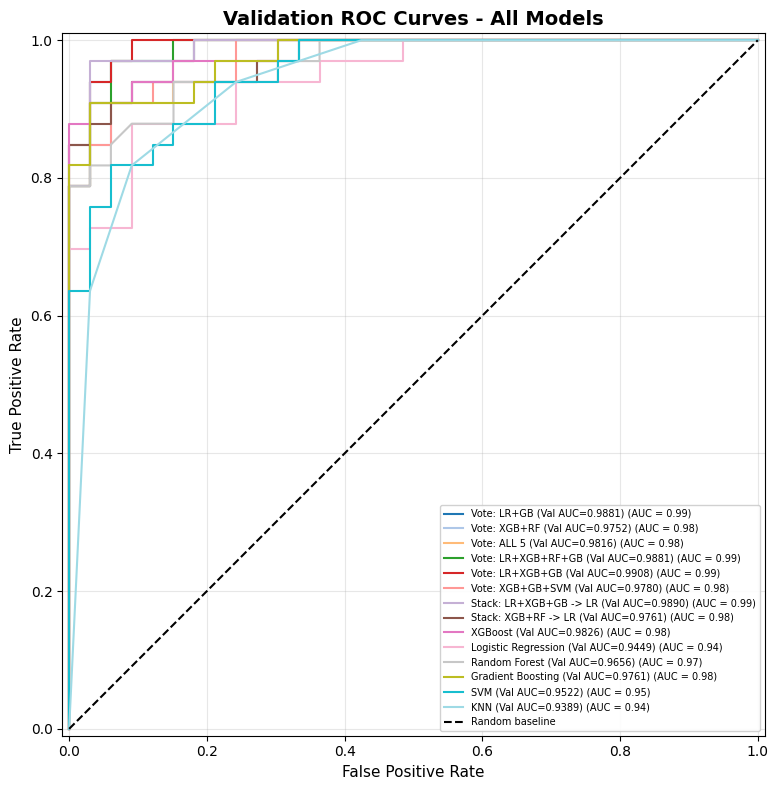

In [8]:
fig, ax = plt.subplots(figsize=(11, 8))

colors = plt.cm.tab20(np.linspace(0, 1, len(results_store)))

for (name, res), color in zip(results_store.items(), colors):
    RocCurveDisplay.from_predictions(
        y_val, res['proba'],
        name=f"{name} (Val AUC={res['auc']:.4f})",
        ax=ax, color=color
    )

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random baseline')
ax.set_title('Validation ROC Curves - All Models', fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.legend(loc='lower right', fontsize=7, framealpha=0.9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curves_all.png', dpi=150, bbox_inches='tight')
plt.show()


## Best Model

In [9]:
# Best model: selected on validation F1(AI), tie-break by validation AUC and accuracy.
# The test split is evaluated only here, after selection is complete.

def make_model_by_name(name):
    factories = {
        'Logistic Regression': make_lr,
        'XGBoost': make_xgb,
        'Random Forest': make_rf,
        'Gradient Boosting': make_gb,
        'SVM': make_svm,
        'KNN': lambda: KNeighborsClassifier(n_neighbors=5),
        'Vote: LR+GB': lambda: VotingClassifier(estimators=[('lr', make_lr()), ('gb', make_gb())], voting='soft'),
        'Vote: XGB+RF': lambda: VotingClassifier(estimators=[('xgb', make_xgb()), ('rf', make_rf())], voting='soft'),
        'Vote: ALL 5': lambda: VotingClassifier(estimators=[('lr', make_lr()), ('xgb', make_xgb()), ('rf', make_rf()), ('gb', make_gb()), ('svm', make_svm())], voting='soft'),
        'Vote: LR+XGB+RF+GB': lambda: VotingClassifier(estimators=[('lr', make_lr()), ('xgb', make_xgb()), ('rf', make_rf()), ('gb', make_gb())], voting='soft'),
        'Vote: LR+XGB+GB': lambda: VotingClassifier(estimators=[('lr', make_lr()), ('xgb', make_xgb()), ('gb', make_gb())], voting='soft'),
        'Vote: XGB+GB+SVM': lambda: VotingClassifier(estimators=[('xgb', make_xgb()), ('gb', make_gb()), ('svm', make_svm())], voting='soft'),
        'Stack: LR+XGB+GB -> LR': lambda: StackingClassifier(estimators=[('lr', make_lr()), ('xgb', make_xgb()), ('gb', make_gb())], final_estimator=make_lr(), cv=5),
        'Stack: XGB+RF -> LR': lambda: StackingClassifier(estimators=[('xgb', make_xgb()), ('rf', make_rf())], final_estimator=make_lr(), cv=5),
    }
    return factories[name]()

def file_sha256(path):
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        for block in iter(lambda: f.read(1024 * 1024), b''):
            h.update(block)
    return h.hexdigest()

best_name = leaderboard_df.iloc[0]['Model']
validation_res = results_store[best_name]

X_trainval = np.vstack([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])

final_scaler = StandardScaler()
X_trainval_s = final_scaler.fit_transform(X_trainval)
X_test_final_s = final_scaler.transform(X_test)

best_model = make_model_by_name(best_name)
best_model.fit(X_trainval_s, y_trainval)

test_pred  = best_model.predict(X_test_final_s)
test_proba = best_model.predict_proba(X_test_final_s)[:, 1]
test_acc   = accuracy_score(y_test, test_pred)
test_auc   = roc_auc_score(y_test, test_proba)
test_rep   = classification_report(y_test, test_pred, target_names=['Human', 'AI'], output_dict=True, zero_division=0)
test_cm    = confusion_matrix(y_test, test_pred)

tn, fp, fn, tp = test_cm.ravel()
best_res = {
    'model': best_model,
    'pred': test_pred,
    'proba': test_proba,
    'acc': test_acc,
    'auc': test_auc,
    'f1': test_rep['AI']['f1-score'],
    'precision_ai': test_rep['AI']['precision'],
    'recall_ai': test_rep['AI']['recall'],
    'cm': test_cm,
    'split': 'test',
    'fp': int(fp),
    'fn': int(fn),
}

scaler = final_scaler

metadata = {
    'project': 'AI vs Human Music Detector',
    'production_notebook': '02_train_model.ipynb',
    'dataset': DATASET_PATH,
    'dataset_sha256': file_sha256(DATASET_PATH),
    'feature_count': len(feature_cols),
    'model_selection_split': 'validation',
    'final_evaluation_split': 'test',
    'selected_model': best_name,
    'selection_metric': 'validation F1(AI), tie-break validation AUC and accuracy',
    'validation_metrics': {
        'accuracy': float(validation_res['acc']),
        'roc_auc': float(validation_res['auc']),
        'f1_ai': float(validation_res['f1']),
    },
    'test_metrics': {
        'accuracy': float(best_res['acc']),
        'roc_auc': float(best_res['auc']),
        'precision_ai': float(best_res['precision_ai']),
        'recall_ai': float(best_res['recall_ai']),
        'f1_ai': float(best_res['f1']),
        'false_positives': int(best_res['fp']),
        'false_negatives': int(best_res['fn']),
    },
    'random_state': RANDOM_STATE,
    'ai_threshold': 0.5,
    'created_at': datetime.now().isoformat(timespec='seconds'),
    'notes': 'Model selected without using the test set; final artifact refit on train+validation and evaluated once on test.',
}

joblib.dump(best_model,   'model.pkl')
joblib.dump(scaler,       'scaler.pkl')
joblib.dump(feature_cols, 'feature_cols.pkl')
with open('metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2)
leaderboard_df.to_csv('validation_leaderboard.csv', index=False)

print('BEST MODEL SELECTED FROM VALIDATION')
print('-' * 55)
print(f'  Name              : {best_name}')
print(f'  Validation Acc    : {validation_res["acc"]*100:.1f}%')
print(f'  Validation ROC-AUC: {validation_res["auc"]:.4f}')
print(f'  Validation F1(AI) : {validation_res["f1"]:.3f}')
print()
print('FINAL TEST EVALUATION')
print('-' * 55)
print(f'  Test Accuracy     : {best_res["acc"]*100:.1f}%')
print(f'  Test ROC-AUC      : {best_res["auc"]:.4f}')
print(f'  Test F1(AI)       : {best_res["f1"]:.3f}')
print(f'  FP / FN           : {best_res["fp"]} / {best_res["fn"]}')
print('\nSaved:')
print('  model.pkl')
print('  scaler.pkl')
print('  feature_cols.pkl')
print('  metadata.json')
print('  validation_leaderboard.csv')


BEST MODEL SELECTED FROM VALIDATION
-------------------------------------------------------
  Name              : Vote: LR+XGB+GB
  Validation Acc    : 93.9%
  Validation ROC-AUC: 0.9908
  Validation F1(AI) : 0.943

FINAL TEST EVALUATION
-------------------------------------------------------
  Test Accuracy     : 93.9%
  Test ROC-AUC      : 0.9871
  Test F1(AI)       : 0.941
  FP / FN           : 3 / 1

Saved:
  model.pkl
  scaler.pkl
  feature_cols.pkl
  metadata.json
  validation_leaderboard.csv


## Best Model : Detailed Report & Confusion Matrix

Final Test Classification Report - Vote: LR+XGB+GB
-------------------------------------------------------
              precision    recall  f1-score   support

       Human       0.97      0.91      0.94        33
          AI       0.91      0.97      0.94        33

    accuracy                           0.94        66
   macro avg       0.94      0.94      0.94        66
weighted avg       0.94      0.94      0.94        66



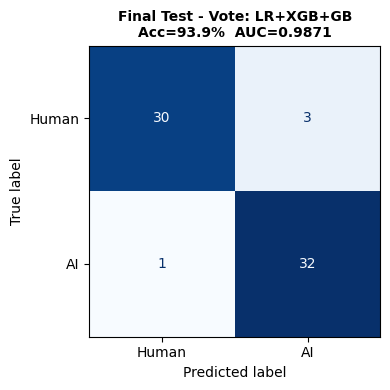

In [10]:
print(f'Final Test Classification Report - {best_name}')
print('-' * 55)
print(classification_report(y_test, best_res['pred'], target_names=['Human', 'AI'], zero_division=0))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(best_res['cm'], display_labels=['Human', 'AI']).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Final Test - {best_name}\nAcc={best_res["acc"]*100:.1f}%  AUC={best_res["auc"]:.4f}', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('best_model_cm.png', dpi=150, bbox_inches='tight')
plt.show()

## Final Leaderboard Summary Table

In [11]:
display_df = leaderboard_df.copy()
display_df['Acc'] = display_df['Acc'].apply(lambda x: f'{x*100:.1f}%')
display_df['AUC'] = display_df['AUC'].apply(lambda x: f'{x:.4f}')
display_df['Prec(AI)'] = display_df['Prec(AI)'].apply(lambda x: f'{x:.3f}')
display_df['Rec(AI)'] = display_df['Rec(AI)'].apply(lambda x: f'{x:.3f}')
display_df['F1(AI)'] = display_df['F1(AI)'].apply(lambda x: f'{x:.3f}')
display_df = display_df.set_index('Rank')

print(f'Best model selected on validation: {best_name}')
print(f'Final test accuracy: {best_res["acc"]*100:.1f}% | Final test AUC: {best_res["auc"]:.4f}')
try:
    from IPython.display import display
    display(display_df.style.set_caption('Validation Leaderboard'))
except Exception:
    print(display_df.to_string())

Best model selected on validation: Vote: LR+XGB+GB
Final test accuracy: 93.9% | Final test AUC: 0.9871


,Model,Acc,AUC,Prec(AI),Rec(AI),F1(AI),FP,FN
Rank,,,,,,,,
1,Vote: LR+XGB+GB,93.9%,0.9908,0.892,1.000,0.943,4,0
2,Vote: LR+XGB+RF+GB,90.9%,0.9881,0.865,0.970,0.914,5,1
3,Vote: ALL 5,90.9%,0.9816,0.865,0.970,0.914,5,1
4,Stack: XGB+RF -> LR,90.9%,0.9761,0.886,0.939,0.912,4,2
5,Vote: XGB+RF,90.9%,0.9752,0.886,0.939,0.912,4,2
6,Stack: LR+XGB+GB -> LR,89.4%,0.9890,0.842,0.970,0.901,6,1
7,Vote: LR+GB,89.4%,0.9881,0.842,0.970,0.901,6,1
8,Random Forest,89.4%,0.9656,0.861,0.939,0.899,5,2
9,XGBoost,87.9%,0.9826,0.821,0.970,0.889,7,1
